In [2]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt, exp, log
from typing import Callable

# Exercise 1
### Generalisation Bound: $4m_H(2N) e^{-\epsilon^2 N / 8}$
### a) Complete generalisation_bound() by converting the function into code
### b) Plot the generalisation bound that you got acquainted with in the lecture by inserting a fitting growth function.

In [3]:


def generalisation_bound(growth_function : Callable[[int],int], accuracy : float = 0.01, n : int = 2000000):
    plots = np.empty((0,))
    i = 1
    while i < n:
        i = i + 1000
        plots = np.append(plots, 4 * growth_function(2 * i) * np.exp(- (accuracy ** 2) * i / 8))
    return normalize(plots)

def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

In [4]:
def growth_function(n : int) -> int:
    return  n // 2

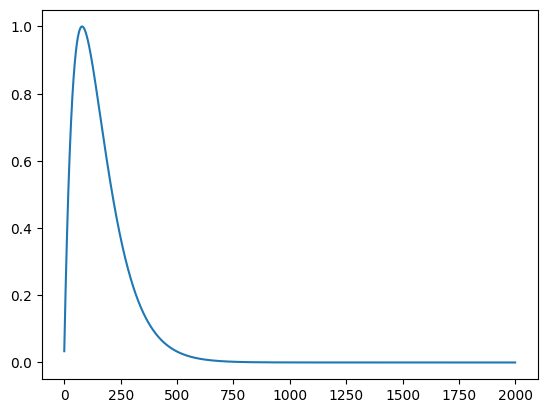

In [5]:
plt.plot(generalisation_bound(growth_function))

# Exercise 2
### You are given 2 different models: A regression model and a classifier model.

### a) Run the models with increasingly larger test samples. (N=100 -> N=1000 -> N=100000 -> no limit)

In [6]:
from easy_models import EasyRegressionModel, EasyNNClassifierModel
easy_reg = EasyRegressionModel("age_income_years_worked.csv")
easy_class= EasyNNClassifierModel("age_income_years_worked.csv")

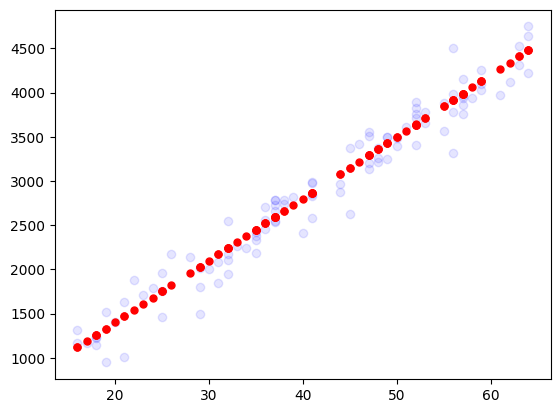

In [7]:
##Regression
#Use limit_test(N) to limit the test sample size max.20000
#Use predict()
#Use plot() to plot the regression
#Use calculate_mse() to get the trained and tested mean square errors
#For troubleshooting reasons we recommend rerunning the cell above.

easy_reg.limit_test(100)
easy_reg.predict()
easy_reg.plot()


In [8]:
## Classifier
#Use limit_test(N) to limit the test sample size max.20000
#Use train() to train the model
#Use calculate_error_ratio()
#For troubleshooting reasons we recommend rerunning the first cell of this exercise.

easy_class.limit_test(3000)
easy_class.train()
easy_class.calculate_error_ratio()


Test Error Ratio =  [0.94876913]
Train Error Ratio =  [0.89090185]


### b) Take note of the change in accuracy of the models.

The error ratio for foreign data decreases with increasing sample size.

#  Exercise 3
## $$ E_{out}(h) \leq E_{in}(h) + \sqrt{\frac{8}{N} \log \frac{4 m_H(2N)}{\delta}} $$

### Find an $N$ for which $E_{out}$ is within 10%, 5% and 1% of $E_{in}$ with the provided growth function. Assume that $E_{in}$ has a probability of 3% and that the inequality holds with $95$% certainty, i.e. that $\delta = 5$%.
### The provided growth_function is $m_H(N) =3N^3 + 2N^2 + 4$.



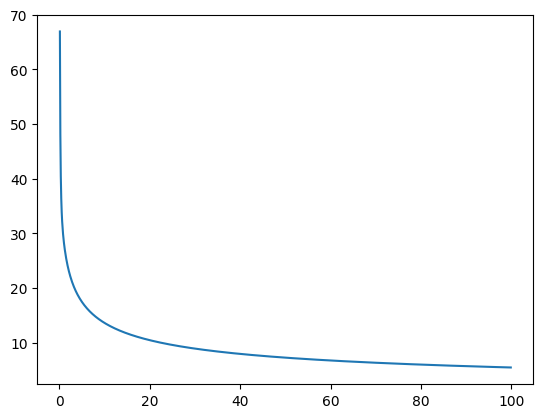

In [11]:
# Your Code here

def mH(n:float):
    return 3 * n **3 + 2 * n ** 2 + 4

def eout(n :float) -> float:
    return .03 + np.sqrt(8 / n * np.log(4 * mH(2 * n)) / .05 )



table:list[tuple[float, float]] = [(n/10, eout(n/10)) for n in range(1, 1000)]

x, y = zip(*table)


plt.plot(x, y)





In [10]:
count = 0



while True:
    count += 0.1

    if eout(count) < .1:
        print(f"10%: {count}")
        break

while True:


    if eout(count) < .5:
        print(f"5%: {count}")
        break

while True:

    if eout(count) < .01:
        print(f"1%: {count}")
        break

10%: 1545011.4002900068
5%: 1545011.4002900068


KeyboardInterrupt: 

# Exercise 4
### Calculate a confusion matrix for the classifier that you've used in exercise 2.

In [ ]:
# Your Code here
# Use predict_test() for predicted values and actual values

# Exercise 5
### Research characteristic traits of the different Machine Learning concepts mentioned in the lecture.

# Exercise 6
### a) Note down 3 different everyday examples of "AI" and assign them to a node of the graph from the lecture.
### b) Also note down the kind of input data.